# Coding Exercises (Part 5)

Now, you will have the opportunity to practice what you have learned. <br>
__Follow the instructions__ and insert your code! 

If you need some help or if you want to check your code, you can also have a look at the __solutions__.

### Have Fun!

--------------------------------------------------------------------------------------------------------------

## Exercise 4: Fama-French 5 - Factor Models

 ### Fama French Model: 6-Factor (Modern)
| Year   | Model                | Regression Formula                                                                          |
| ------ | -------------------- | ------------------------------------------------------------------------------------------- |
| Modern | Fama – French 6-Factor | $ R_i-R_f=\alpha+\beta_M(MKT-RF)+\beta_SSMB+\beta_HHML+\beta_RRMW+\beta_CCMA+\beta_{Mom}MOM  $|

<br>

| Year | Factor        | Abbreviation          | Meaning                       | Intuition & Example |Formula                                   |Beta Interpretation (β)|
| ---- | ------------- | --------------------- | ----------------------------- |-------------------- |----------------------------------------- |-----------------------|
| 1964 | Market        | **MKT-RF**            | Market excess return          |The Story: The market's overall performance drives most stock returns.<br>Example: The S&P 500 returned 10% last year, and the risk-free rate was 2%. The MKT-RF would be +8%. This is the baseline reward for simply being in the market.                                                                                              |$ MKT-RF = R_M - R_f$                     | (+): Stock moves with the market (e.g., most stocks). (-): Stock moves against the market (rare, like gold miners or inverse ETFs). <br> Buffett: ~0.8 (steady, buys dips). <br> Lynch: ~1.1 (aggressive when he finds winners).
| 1993 | Size          | **SMB**               | Small Minus Big               |The Story: Small companies are riskier but can grow more, so they offer a premium. <br> Example: A portfolio of small-cap stocks returned 15%, while large-caps returned 10%. SMB is +5%, meaning the market is rewarding you for the extra risk of investing in smaller firms.                                                            |$ SMB = R_{\text{Small Cap}} - R_{\text{Big Cap}}$               | (+): Stock acts like a Small-cap company (rides the small-cap wave).<br> (-): Stock acts like a Large-cap company (moves with the giants).<br> Buffett: - (loves mega-caps with moats). <br> Lynch: + (loves small, overlooked gems).
| 1993 | Value         | **HML**               | High Minus Low                |The Story: Out-of-favor, cheap stocks are riskier but can have higher returns. <br>Example: A portfolio of value stocks (e.g., old industrial companies) returned 12%, while growth stocks (e.g., high-flying tech) returned 6%. HML is +6%, a premium for buying "unloved" stocks.                                                       |$ HML = R_{Value} - R_{Growth}$            | (+): Stock acts like a Value stock (cheap, high book-to-market, boring).<br> (-): Stock acts like a Growth stock (expensive, low book-to-market, exciting). <br> Buffett: Positive (buys quality on sale). <br> Lynch: Negative (buys high-growth earnings).
| 1997 | Momentum      | **MOM** (or UMD, WML) | Winners Minus Losers          |The Story: Markets have short-term memory. Past performance can persist for a few months.<br> Example: A portfolio of stocks that were the top performers last year returned 14%, while past losers returned 2%. MOM is +12%, capturing this short-term trend.                                                                         |$ MOM = R_{Winners} - R_{Losers}$          | (+): Stock rides the trend (momentum chaser—winners keep winning). <br> (-): Stock reverses the trend (contrarian—winners fall, losers bounce). <br> Buffett: - (buys what's hated and beaten down). <br> Lynch: - (buys what's boring and forgotten).
| 2015 | Profitability | **RMW**               | Robust Minus Weak             |The Story: Profitable companies are fundamentally stronger and less risky, so they should offer a higher return. <br> Example: A portfolio of companies with robust profit margins returned 11%, while weak ones returned 5%. RMW is +6%, a premium for investing in high-quality, profitable businesses.                                     |$ RMW = R_{Robust} - R_{Weak}$             | (+): Stock acts like a highly profitable company (strong cash flows, pricing power). <br> (-): Stock acts like an unprofitable company (burning cash, speculative). <br> Buffett: Strongly + (moats = profitability). <br> Lynch: + (loves earnings growth).
| 2015 | Investment    | **CMA**               | Conservative Minus Aggressive |The Story: Companies that plow money into aggressive expansion are riskier and often have lower returns. <br> Example: A portfolio of companies that conservatively reinvested returned 10%, while aggressive expanders returned 4%. CMA is +6%, a reward for prudent investment strategy.                         |$ CMA = R_{Conservative} - R_{Aggressive}$ | (+): Stock acts like a conservative company (low asset growth, steady, sustainable). <br> (-): Stock acts like an aggressive company (rapid expansion, high debt, risky). <br> Buffett: Strongly + (avoids overexpansion and expensive acquisitions). <br> Lynch: Mildly + (wants growth, but not reckless, debt-fueled growth).


Create a __Fama-French Five-Factor Model__ for __Walmart__ (WMT) using daily price data from  __Jan-01-2000__ until __Dec-31-2009__. <br> <br>
Which Factors are __significant__ and is Walmarts __Alpha significant__ (required level of significance: 1%)? How would you __categorize__ Walmart (cyclical vs. non-cyclical, value vs. growth, etc.)?

In [25]:
#run the cell!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.formula.api import ols
%config InlineBackened.figure_format = "svg"

In [4]:
#run the cell!
df = pd.read_csv("F-F_Research_Data_5_Factors_2x3_daily.CSV", 
                 skiprows = 3, 
                 parse_dates = [0], 
                 index_col = 0)

In [5]:
df

,Mkt-RF,SMB,HML,RMW,CMA,RF
1963-07-01,-0.67,0.00,-0.32,-0.01,0.15,0.012
1963-07-02,0.79,-0.27,0.27,-0.07,-0.19,0.012
1963-07-03,0.63,-0.17,-0.09,0.17,-0.33,0.012
1963-07-05,0.40,0.08,-0.28,0.08,-0.33,0.012
1963-07-08,-0.63,0.04,-0.18,-0.29,0.13,0.012
...,...,...,...,...,...,...
2019-12-24,0.01,0.36,-0.07,-0.28,0.02,0.007
2019-12-26,0.49,-0.56,0.00,0.23,-0.19,0.007
2019-12-27,-0.09,-0.54,-0.07,0.24,0.16,0.007
2019-12-30,-0.57,0.27,0.58,0.15,0.45,0.007


In [6]:
#run the cell!
wmt = yf.download("WMT", start = "1999-12-31", end = "2009-12-31", multi_level_index= False)

[*********************100%***********************]  1 of 1 completed


In [7]:
wmt = wmt["Close"]
wmt

Date
1999-12-31    14.644455
2000-01-03    14.154537
2000-01-04    13.624906
2000-01-05    13.346840
2000-01-06    13.492496
                ...    
2009-12-23    12.692565
2009-12-24    12.759221
2009-12-28    12.849681
2009-12-29    12.880626
2009-12-30    12.925855
Name: Close, Length: 2515, dtype: float64

__Now it´s your turn!__

In [8]:
wmt_ret = wmt.pct_change().dropna()
wmt_ret = wmt_ret * 100
wmt_ret

Date
2000-01-03   -3.345415
2000-01-04   -3.741780
2000-01-05   -2.040863
2000-01-06    1.091319
2000-01-07    7.556410
                ...   
2009-12-23   -0.037547
2009-12-24    0.525159
2009-12-28    0.708976
2009-12-29    0.240822
2009-12-30    0.351139
Name: Close, Length: 2514, dtype: float64

In [9]:
df["WMT_RET"] = wmt_ret

In [12]:
df["WMT"] = wmt

In [13]:
df

,Mkt-RF,SMB,HML,RMW,CMA,RF,WMT_RET,WMT
1963-07-01,-0.67,0.00,-0.32,-0.01,0.15,0.012,NaN,NaN
1963-07-02,0.79,-0.27,0.27,-0.07,-0.19,0.012,NaN,NaN
1963-07-03,0.63,-0.17,-0.09,0.17,-0.33,0.012,NaN,NaN
1963-07-05,0.40,0.08,-0.28,0.08,-0.33,0.012,NaN,NaN
1963-07-08,-0.63,0.04,-0.18,-0.29,0.13,0.012,NaN,NaN
...,...,...,...,...,...,...,...,...
2019-12-24,0.01,0.36,-0.07,-0.28,0.02,0.007,NaN,NaN
2019-12-26,0.49,-0.56,0.00,0.23,-0.19,0.007,NaN,NaN
2019-12-27,-0.09,-0.54,-0.07,0.24,0.16,0.007,NaN,NaN
2019-12-30,-0.57,0.27,0.58,0.15,0.45,0.007,NaN,NaN


In [15]:
df = df.dropna()

In [16]:
df

,Mkt-RF,SMB,HML,RMW,CMA,RF,WMT_RET,WMT
2000-01-03,-0.71,-0.16,-0.85,-1.40,-0.77,0.021,-3.345415,14.154537
2000-01-04,-4.06,0.33,2.21,0.33,1.46,0.021,-3.741780,13.624906
2000-01-05,-0.09,0.31,0.14,0.36,1.01,0.021,-2.040863,13.346840
2000-01-06,-0.73,-0.13,1.38,0.53,1.20,0.021,1.091319,13.492496
2000-01-07,3.21,-0.97,-1.24,-0.79,-0.95,0.021,7.556410,14.512045
...,...,...,...,...,...,...,...,...
2009-12-23,0.36,0.88,-0.39,0.44,-0.16,0.000,-0.037547,12.692565
2009-12-24,0.51,-0.07,0.20,-0.14,-0.04,0.000,0.525159,12.759221
2009-12-28,0.08,-0.18,-0.28,0.11,-0.16,0.000,0.708976,12.849681
2009-12-29,-0.09,0.07,-0.08,-0.06,0.00,0.000,0.240822,12.880626


In [17]:
df["WMTPremium"] = df["WMT_RET"] - df["RF"]

C:\Users\ahmad\AppData\Local\Temp\ipykernel_30544\3053504009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["WMTPremium"] = df["WMT_RET"] - df["RF"]


In [19]:
df.rename(columns = {"Mkt-RF":"MktPremium"}, inplace = True)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_30544\1192209282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {"Mkt-RF":"MktPremium"}, inplace = True)


In [21]:
df = df.reindex(columns = ["WMTPremium","MktPremium", "SMB", "HML", "RMW", "CMA" , "RF", "WMT_RET", "WMT"])
df

,WMTPremium,MktPremium,SMB,HML,RMW,CMA,RF,WMT_RET,WMT
2000-01-03,-3.366415,-0.71,-0.16,-0.85,-1.40,-0.77,0.021,-3.345415,14.154537
2000-01-04,-3.762780,-4.06,0.33,2.21,0.33,1.46,0.021,-3.741780,13.624906
2000-01-05,-2.061863,-0.09,0.31,0.14,0.36,1.01,0.021,-2.040863,13.346840
2000-01-06,1.070319,-0.73,-0.13,1.38,0.53,1.20,0.021,1.091319,13.492496
2000-01-07,7.535410,3.21,-0.97,-1.24,-0.79,-0.95,0.021,7.556410,14.512045
...,...,...,...,...,...,...,...,...,...
2009-12-23,-0.037547,0.36,0.88,-0.39,0.44,-0.16,0.000,-0.037547,12.692565
2009-12-24,0.525159,0.51,-0.07,0.20,-0.14,-0.04,0.000,0.525159,12.759221
2009-12-28,0.708976,0.08,-0.18,-0.28,0.11,-0.16,0.000,0.708976,12.849681
2009-12-29,0.240822,-0.09,0.07,-0.08,-0.06,0.00,0.000,0.240822,12.880626


In [22]:
for idx , col in enumerate(df.columns):
    print(idx, col)

0 WMTPremium
1 MktPremium
2 SMB
3 HML
4 RMW
5 CMA
6 RF
7 WMT_RET
8 WMT


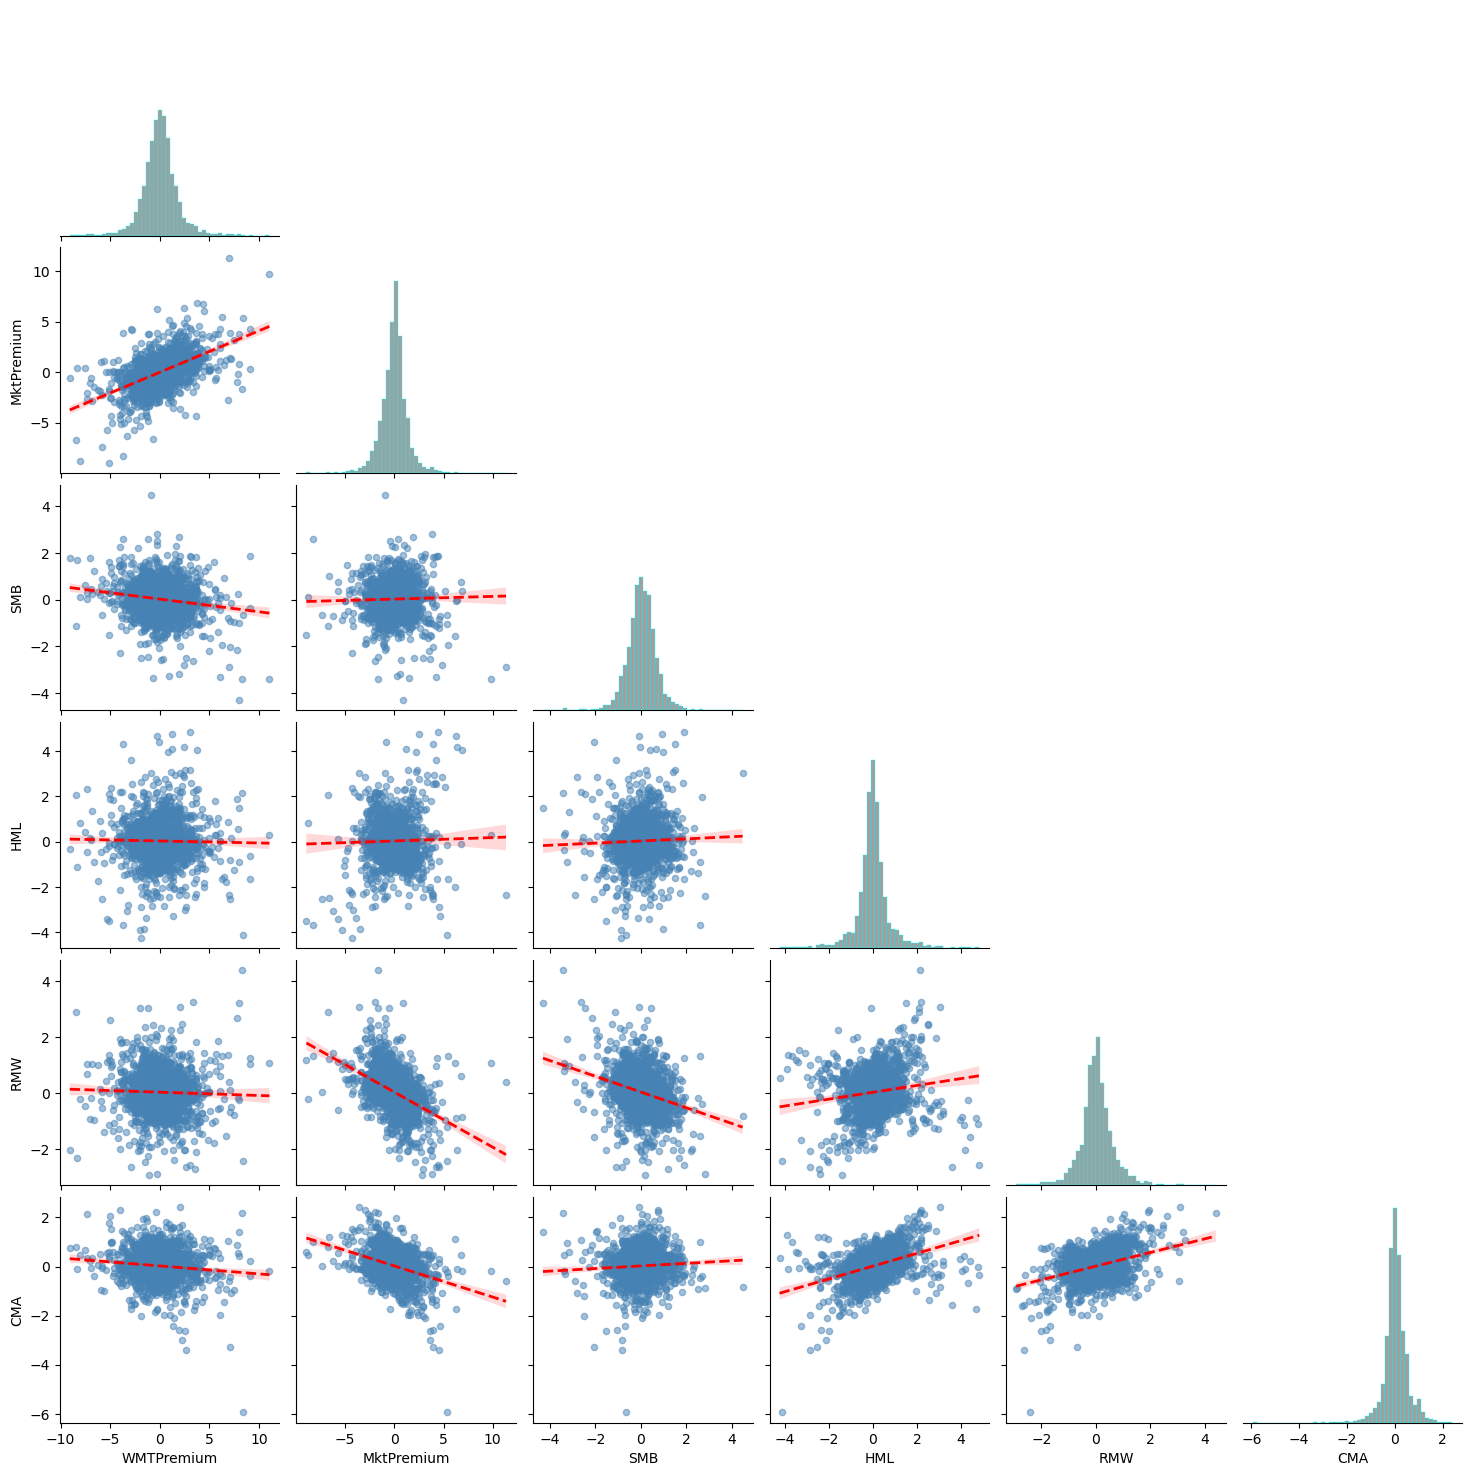

In [53]:
sns.pairplot(df[df.columns[0:6]], 
             kind = "reg", 
             diag_kws = {"color":"gray", "edgecolor":"cyan", "bins":50 ,"lw":4},
             plot_kws = {"line_kws":{"color":"red" ,"ls":"--", "lw":2},
                         "scatter_kws":{"color":"steelblue", "s":20, "alpha":0.5}}, 
            corner = True)
plt.show()

In [60]:
for col in df.columns[:7].drop("WMTPremium"):
    print(col)

MktPremium
SMB
HML
RMW
CMA
RF


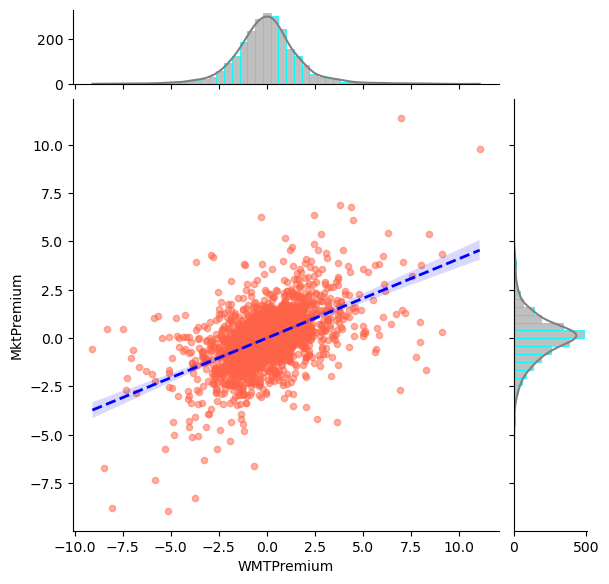

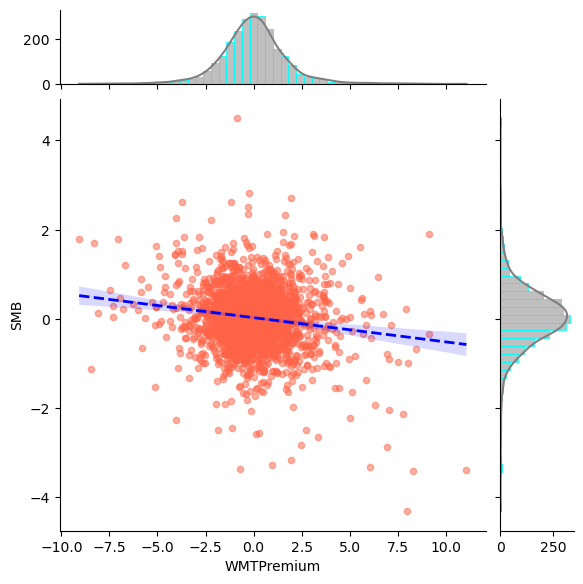

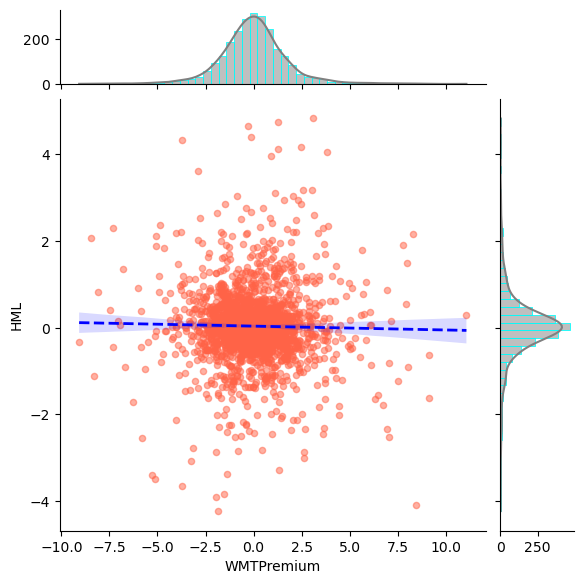

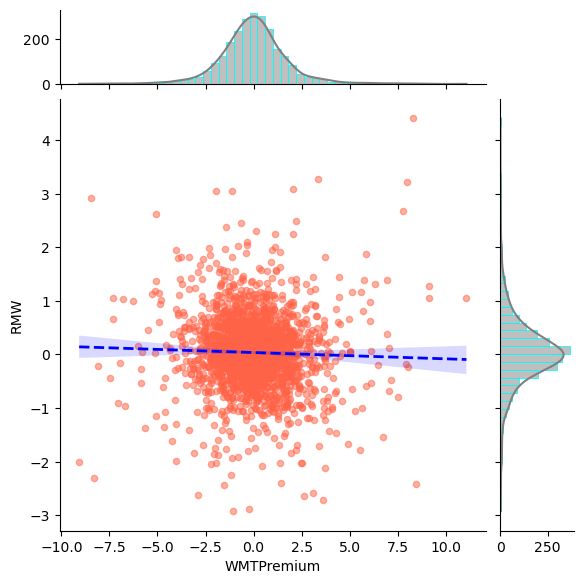

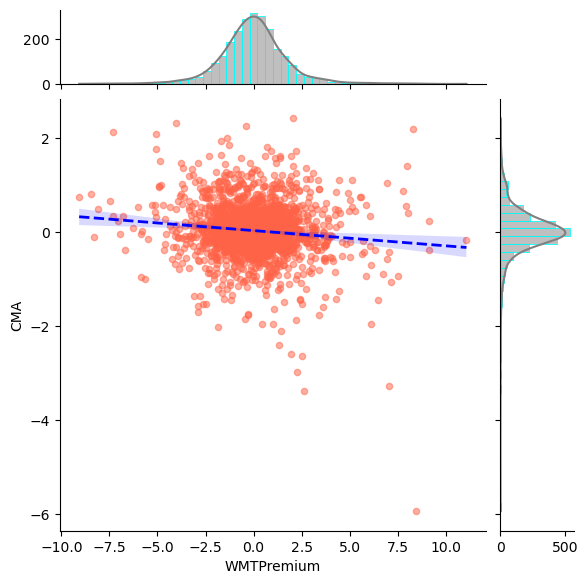

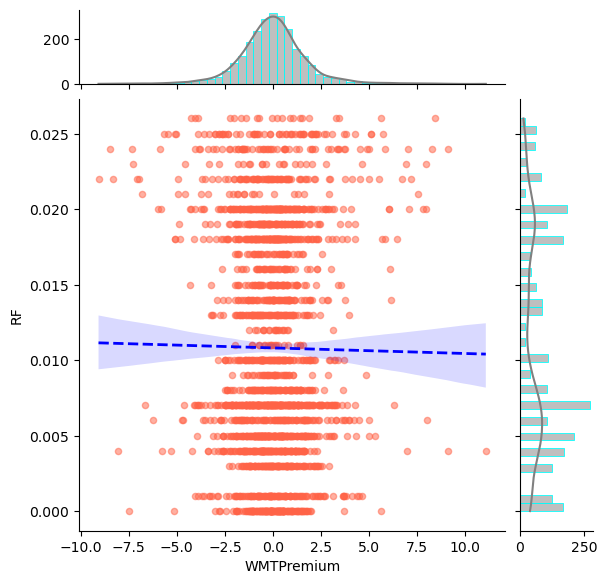

In [61]:
for col in df.columns[:7].drop("WMTPremium"):
    sns.jointplot(x="WMTPremium", y=col, data=df,
                    kind="reg",
                    color="fuchsia",
                    marginal_ticks=True,
                    marginal_kws={"color": "gray", "edgecolor": "cyan" ,"bins":50},
                    line_kws={"color": "blue", "linewidth": 2, "linestyle": "--"},
                    scatter_kws={"color": "tomato", "s": 20, "alpha": 0.5})
    plt.ylabel(col)
    plt.xlabel("WMTPremium")
    plt.show()

In [59]:
for col in df.columns[:7]:
    print(col)

WMTPremium
MktPremium
SMB
HML
RMW
CMA
RF


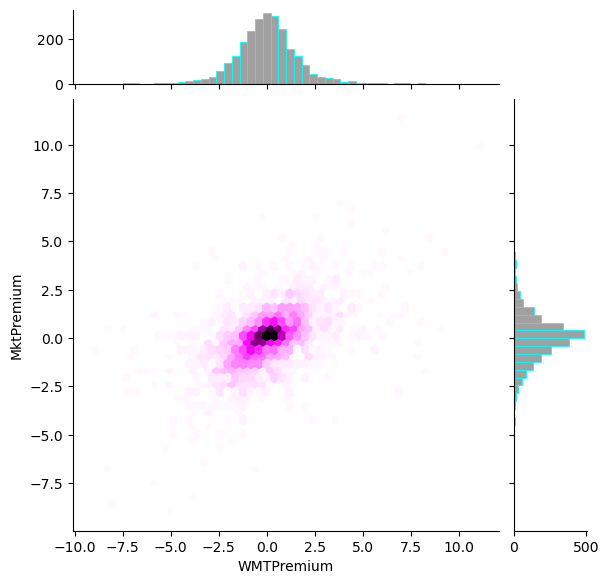

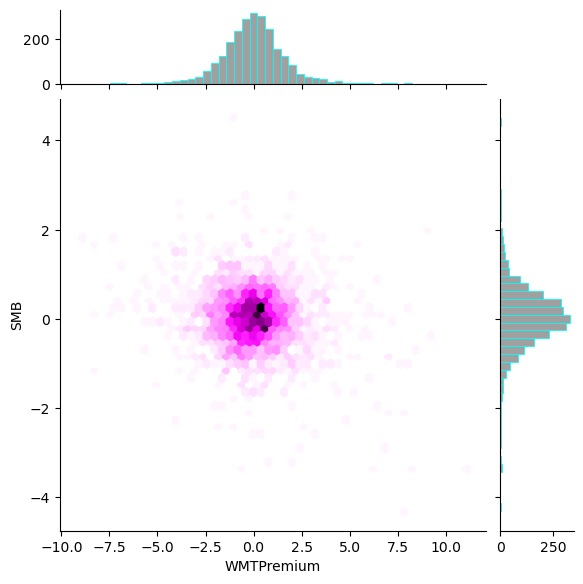

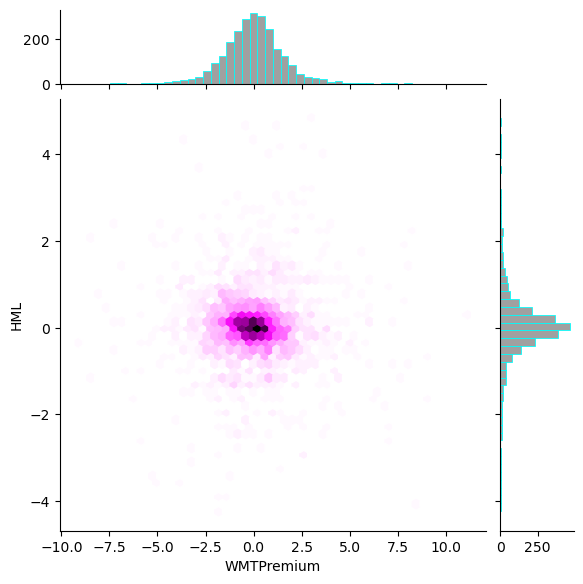

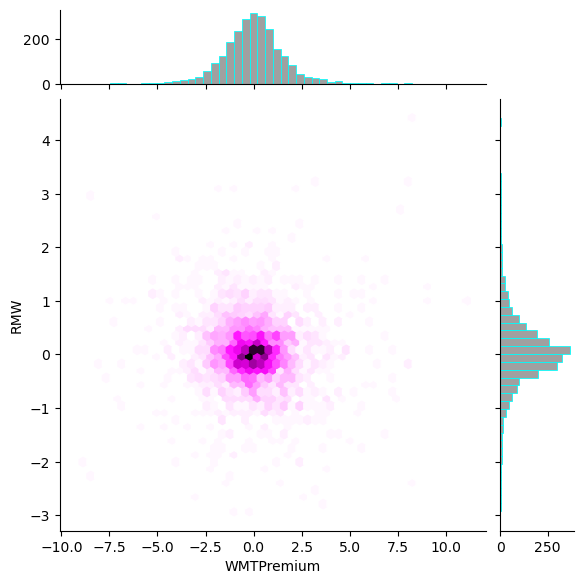

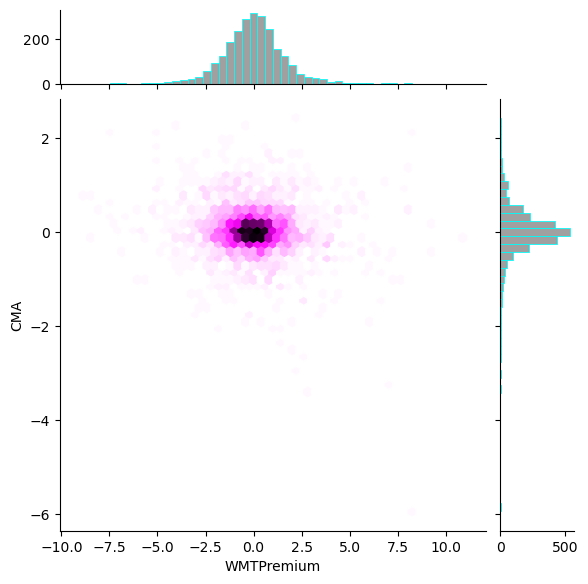

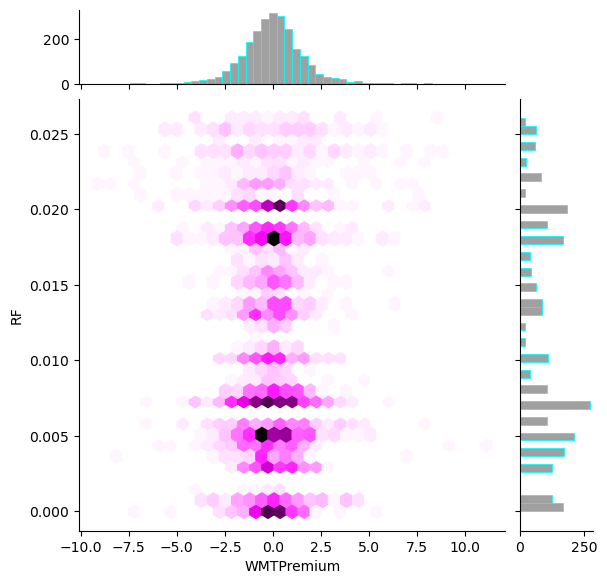

In [62]:
for col in df.columns[:7].drop("WMTPremium"):
    sns.jointplot(x="WMTPremium", y=col, data=df,
                    kind="hex",
                    color="fuchsia",
                    marginal_ticks=True,
                    marginal_kws={"color": "gray", "edgecolor": "cyan" ,"bins":50},
                    #line_kws={"color": "red"}
                    )
    plt.ylabel(col)
    plt.xlabel("WMTPremium")
    plt.show()

In [92]:
df[df.columns[:7]].corr().style.background_gradient(cmap = "coolwarm")

,WMTPremium,MktPremium,SMB,HML,RMW,CMA,RF
WMTPremium,1.000000,0.524025,-0.148054,-0.020349,-0.033145,-0.113426,-0.008846
MktPremium,0.524025,1.000000,0.024487,0.026725,-0.434656,-0.347473,-0.020780
SMB,-0.148054,0.024487,1.000000,0.039646,-0.290927,0.067613,-0.018803
HML,-0.020349,0.026725,0.039646,1.000000,0.151240,0.398341,0.040430
RMW,-0.033145,-0.434656,-0.290927,0.151240,1.000000,0.344409,0.031109
CMA,-0.113426,-0.347473,0.067613,0.398341,0.344409,1.000000,0.042320
RF,-0.008846,-0.020780,-0.018803,0.040430,0.031109,0.042320,1.000000


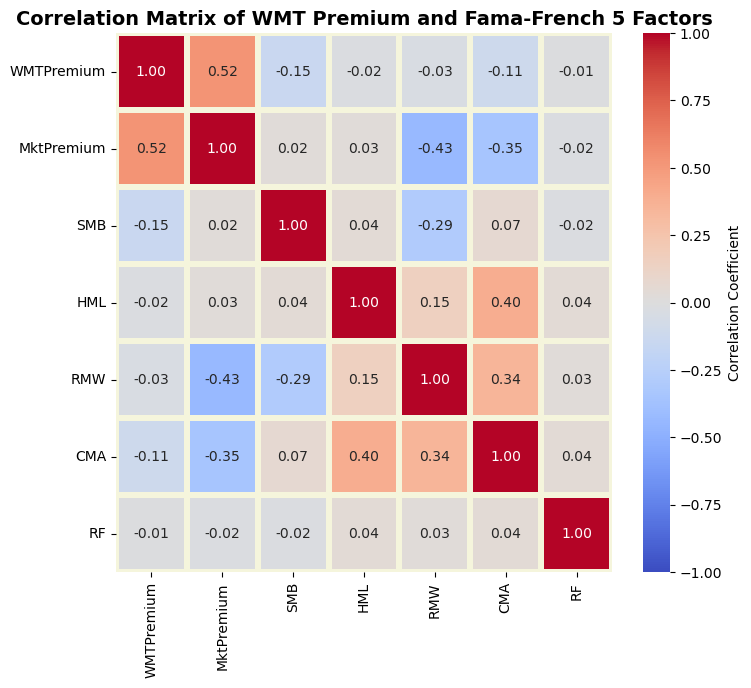

In [94]:
plt.figure(figsize = (8, 7))
sns.heatmap(df[df.columns[:7]].corr(),
            vmin = -1,
            vmax = 1,
            annot = True, 
            fmt = ".2f", 
            cmap = "coolwarm", 
            linewidths = 3, 
            linecolor = "beige", 
            cbar_kws = {"label":"Correlation Coefficient"})

plt.yticks(rotation = 0)
plt.title("Correlation Matrix of WMT Premium and Fama-French 5 Factors", fontsize = 14, fontweight = "bold")
sns.despine( top = True, right = True, left = True, bottom = True)

In [84]:
model_ff5 = ols("WMTPremium ~ MktPremium + SMB + HML + RMW + CMA", data = df).fit()
results_ff5 = model_ff5.summary()
print(results_ff5)

                            OLS Regression Results                            
Dep. Variable:             WMTPremium   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     259.1
Date:                Mon, 29 Jun 2026   Prob (F-statistic):          1.01e-223
Time:                        11:42:35   Log-Likelihood:                -4513.1
No. Observations:                2514   AIC:                             9038.
Df Residuals:                    2508   BIC:                             9073.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0113      0.029     -0.387      0.6

In [ ]:
def model_ff5_info(results):
    alpha = results.params.Intercept
    beta_Mkt = results.params.MktPrem
    beta_SMB = results.params.SMB
    beta_HML = results.params.HML
    beta_RMW = results.params.RMW
    beta_CMA = results.params.CMA

    if alpha > 0.05:
        print("alpha is not significant. So the abnormal return is not significant.")
       
    else:
        print("alpha is significant. So the abnormal return is significant.")

    if beta_Mkt > 1:
        print("stock is more aggressive than the market.")
        
    elif beta_Mkt < 1:
        print("stock is less aggressive than the market.")
        
    else:
        print("stock is neutral to the market.")

    if beta_SMB > 0:
        print("stock behaves like small cap stocks.")

    else:
        print("stock behaves like large cap stocks.")

    if beta_HML > 0:
        print("stock behaves like a value stock.(cheap, high book value)")
        
    else:
        print("stock behaves like a growth stock.(expensive, low book value)")

    if beta_RMW > 0:
        print("Stock acts like a highly profitable company (strong cash flows, pricing power).")
        
    else:
        print("Stock acts like an unprofitable company (burning cash, speculative).")

    if beta_CMA > 0:
        print("Stock acts like a conservative company (low asset growth, steady, sustainable).")
        
    else:
        print("Stock acts like an aggressive company (rapid expansion, high debt, risky).")

    print("="*75)
    print(f"alpha: {alpha:.4f}")
    print(f"beta_Mkt: {beta_Mkt:.4f}")
    print(f"beta_SMB: {beta_SMB:.4f}")
    print(f"beta_HML: {beta_HML:.4f}")
    print(f"beta_MOM: {beta_MOM:.4f}")
    print(f"beta_RMW: {beta_RMW:.4f}")
    print(f"beta_CMA: {beta_CMA:.4f}")


# Well Done!

---------------------------------------------------------------------------------------------------------------------

# Solutions (Stop here if you want to code on your own!)

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Create a __Fama-French Five-Factor Model__ for __Walmart__ (WMT) using daily price data from  __Jan-01-2000__ until __Dec-31-2009__. <br> <br>
Which Factors are __significant__ and is Walmarts __Alpha significant__ (required level of significance: 1%)? How would you __categorize__ Walmart (cyclical vs. non-cyclical, value vs. growth, etc.)?

In [ ]:
#run the cell!
import pandas as pd
import yfinance as yf
from statsmodels.formula.api import ols

In [ ]:
#run the cell!
df = pd.read_csv("F-F_Research_Data_5_Factors_2x3_daily.CSV", skiprows = 3, 
                 parse_dates = [0], index_col = 0)

In [ ]:
#run the cell!
wmt = yf.download("WMT", start = "1999-12-31", end = "2009-12-31", multi_level_index= False)

In [ ]:
df

In [ ]:
df = df.rename(columns = {"Mkt-RF":"MktPrem"})

In [ ]:
df

In [ ]:
wmt

In [ ]:
wmt.index = pd.to_datetime(wmt.index.date) # new

In [ ]:
wmt = wmt.loc[:, "Adj Close"]

In [ ]:
wmt = wmt.pct_change().dropna()

In [ ]:
wmt

In [ ]:
wmt = wmt * 100

In [ ]:
df["WMT"] = wmt

In [ ]:
df = df.dropna().copy()

In [ ]:
df["WMTPrem"] = df.WMT - df.RF

In [ ]:
df

In [ ]:
df.info()

In [ ]:
model = ols("WMTPrem ~ MktPrem + SMB + HML + RMW + CMA", data = df)

In [ ]:
results = model.fit()

In [ ]:
print(results.summary())

In [ ]:
(results.params.Intercept / 100 + 1)**252 - 1